# Obspy Emscripten Overview

In [1]:
# this is required to monkey patch any urllib requests to use urllib3/requests.
# urllib is not WASM compatible. Emscripten tries to automatically reroute any of its download
# requests to a ws:// websocket which fails with a "Mixed content" error on an https:// deployment.

import pyodide_http
pyodide_http.patch_all()  # Patch all libraries

import numpy as np
def fake_memmap(filename, dtype=np.uint8, mode=None, offset=0, shape=None, order=None):
    with open(filename, "rb") as f:
        f.seek(offset)
        data = np.fromfile(f, dtype=dtype)
    if shape is not None:
        data = data.reshape(shape)
    return data

np.memmap = fake_memmap

## What works

### Reading Data

3 Trace(s) in Stream:
BW.KW1..EHE | 2015-11-29T00:00:00.000000Z - 2015-11-29T00:59:59.995000Z | 200.0 Hz, 720000 samples
BW.KW1..EHN | 2015-11-29T00:00:00.000000Z - 2015-11-29T00:59:59.995000Z | 200.0 Hz, 720000 samples
BW.KW1..EHZ | 2015-11-29T00:00:00.000000Z - 2015-11-29T00:59:59.995000Z | 200.0 Hz, 720000 samples


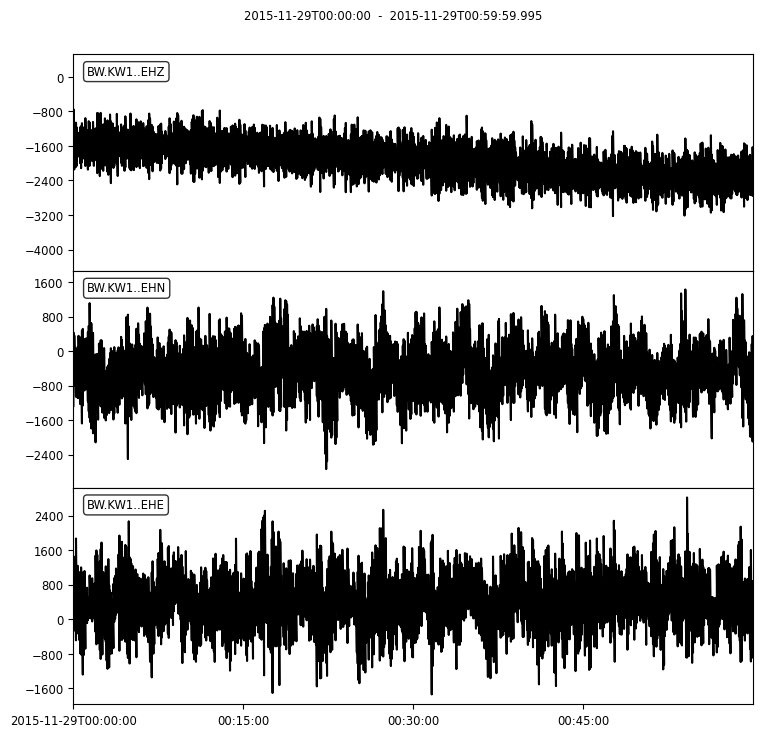

In [2]:
from obspy import read
st = read("data/000000000_0036EE80.mseed")
print(st)
st.plot(); # plots twice without the semicolon. This may be a JupyterLite quirk?

### Filtering

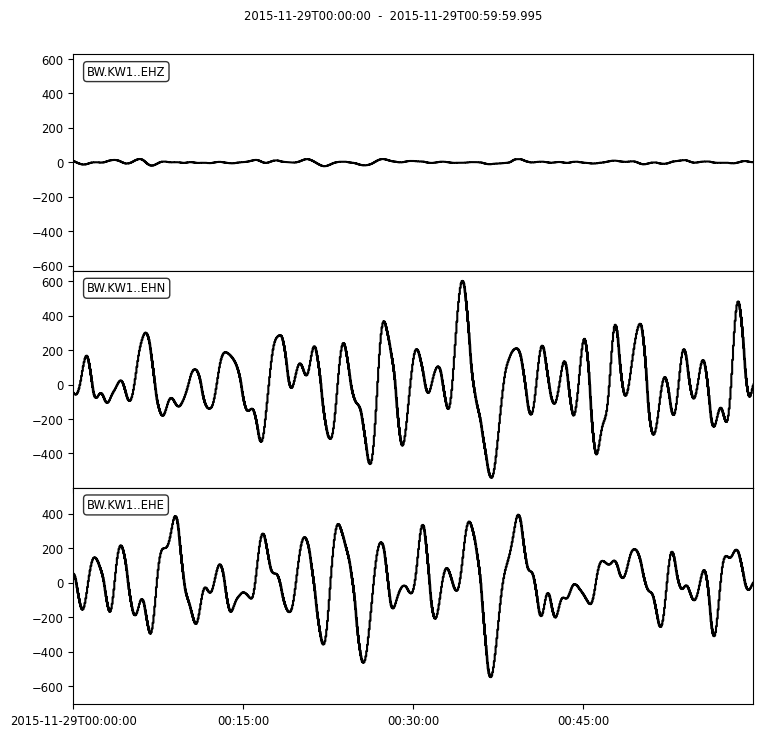

In [3]:
# Apply lowpass filter directly
st_filtered = st.copy()
st_filtered.detrend("spline", order=3, dspline=100000)
st_filtered.filter("lowpass", freq=0.01, corners=2, zerophase=True)
st_filtered.plot();

### Beachballs

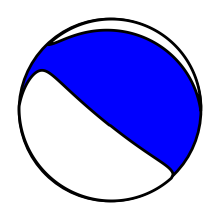

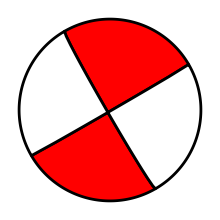

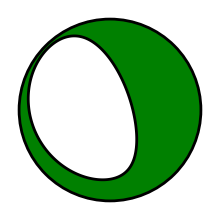

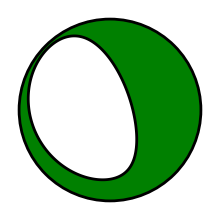

In [4]:
from obspy.imaging.beachball import beachball

mt = [0.91, -0.89, -0.02, 1.78, -1.55, 0.47]
beachball(mt, size=200, linewidth=2, facecolor='b')

mt2 = [150, 87, 1]
beachball(mt2, size=200, linewidth=2, facecolor='r')

mt3 = [-2.39, 1.04, 1.35, 0.57, -2.94, -0.94]
beachball(mt3, size=200, linewidth=2, facecolor='g')

### StationXML

In [5]:
from obspy import read_events, read_inventory
from obspy.core.util import get_example_file 
stations = get_example_file("BW_RJOB.xml") # not all example files from the tutorials are available (see list below)

inv = read_inventory(stations)
print(stations)
print(inv)

/lib/python3.13/site-packages/obspy/core/data/BW_RJOB.xml
Inventory created at 2013-12-07T18:00:42.878000Z
	Created by: fdsn-stationxml-converter/1.0.0
		    http://www.iris.edu/fdsnstationconverter
	Sending institution: Erdbebendienst Bayern
	Contains:
		Networks (1):
			BW
		Stations (1):
			BW.RJOB (Jochberg, Bavaria, BW-Net)
		Channels (3):
			BW.RJOB..EHZ, BW.RJOB..EHN, BW.RJOB..EHE


In [6]:
events = read_events("data/array_1991-12-17_event.xml")
print(events)

1 Event(s) in Catalog:
1991-12-17T06:38:14.060000Z | +47.425, +151.536 | 5.7  mw


### Plotting maps (local data)

/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/lib/python3.13/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


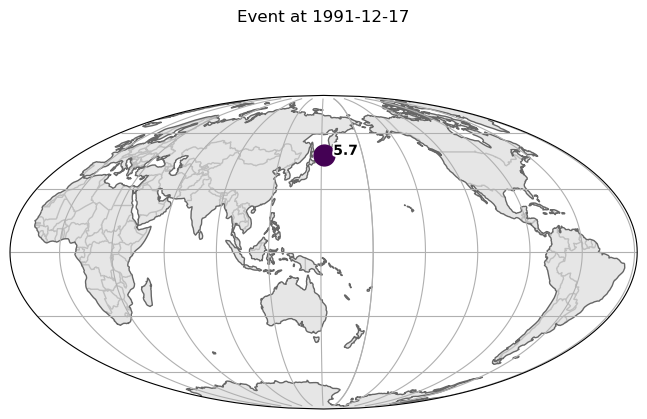

In [7]:
events.plot();

/lib/python3.13/site-packages/obspy/imaging/beachball.py:193: UserWarning: There is a known bug when plotting semi-transparent patches for non-DC sources, which leads to blending of pressure and tension color, see issue #1464.
  warnings.warn(msg)


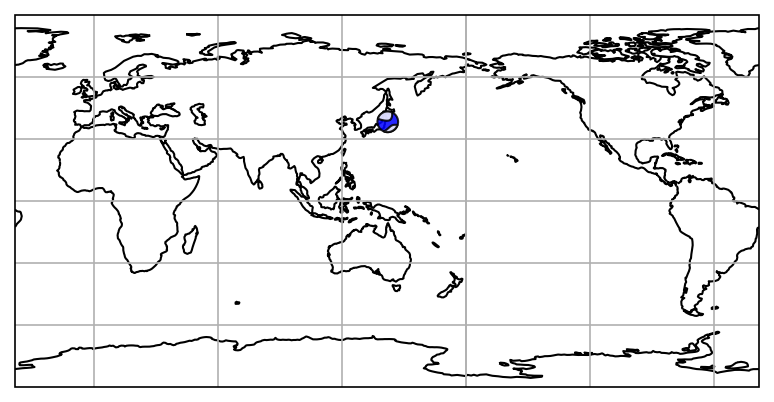

In [8]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from obspy import read_inventory, read_events
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from obspy.imaging.beachball import beach

projection = ccrs.PlateCarree(central_longitude=142.0)

fig = plt.figure(dpi=150)
ax = fig.add_subplot(111, projection=projection)
ax.set_extent((-180, 180, -90, 90))
ax.coastlines()
ax.gridlines()

x, y = projection.transform_point(x=142.36929, y=38.3215, src_crs=ccrs.Geodetic())
focmecs = [0.136, -0.591, 0.455, -0.396, 0.046, -0.615]

ax = plt.gca()
b = beach(focmecs, xy=(x, y), width=10, linewidth=1, alpha=0.85)
b.set_zorder(10)
ax.add_collection(b)

plt.show()

### PPSD

In [9]:
from obspy import read, read_inventory
from obspy.io.xseed import Parser
from obspy.signal import PPSD
inv = read_inventory("data/BW_KW1.xml")
st = read("data/BW.KW1..EHZ.D.2011.037")
print(inv)
print(st)

Inventory created at 2018-04-25T13:30:17.000000Z
	Created by: JANE WEB SERVICE: fdsnws-station | Jane version: 0.0.0+archive
		    http://jane/fdsnws/station/1/query?station=KW1&level=response
	Sending institution: Jane (Jane)
	Contains:
		Networks (1):
			BW
		Stations (1):
			BW.KW1 (Garching, Kirchweidach, BW-Net)
		Channels (15):
			BW.KW1..BHZ (2x), BW.KW1..BHN (2x), BW.KW1..BHE (2x), BW.KW1..EHZ, 
			BW.KW1..EHN, BW.KW1..EHE, BW.KW1..HHZ (2x), BW.KW1..HHN (2x), 
			BW.KW1..HHE (2x)
3 Trace(s) in Stream:
BW.KW1..EHZ | 2011-02-06T00:00:00.935000Z - 2011-02-06T05:07:21.115000Z | 200.0 Hz, 3688037 samples
BW.KW1..EHZ | 2011-02-06T05:50:15.079999Z - 2011-02-06T06:07:21.514999Z | 200.0 Hz, 205288 samples
BW.KW1..EHZ | 2011-02-06T07:49:55.940000Z - 2011-02-07T00:00:01.130000Z | 200.0 Hz, 11641039 samples


In [10]:
st_decimated = st.copy()
st_decimated.filter("lowpass", freq=1)
st_decimated.decimate(20, no_filter=True)

3 Trace(s) in Stream:
BW.KW1..EHZ | 2011-02-06T00:00:00.935000Z - 2011-02-06T05:07:21.035000Z | 10.0 Hz, 184402 samples
BW.KW1..EHZ | 2011-02-06T05:50:15.079999Z - 2011-02-06T06:07:21.479999Z | 10.0 Hz, 10265 samples
BW.KW1..EHZ | 2011-02-06T07:49:55.940000Z - 2011-02-07T00:00:01.040000Z | 10.0 Hz, 582052 samples

In [11]:
ppsd = PPSD(st_decimated[0].stats, metadata=inv)

In [12]:
ppsd.add(st_decimated)

True

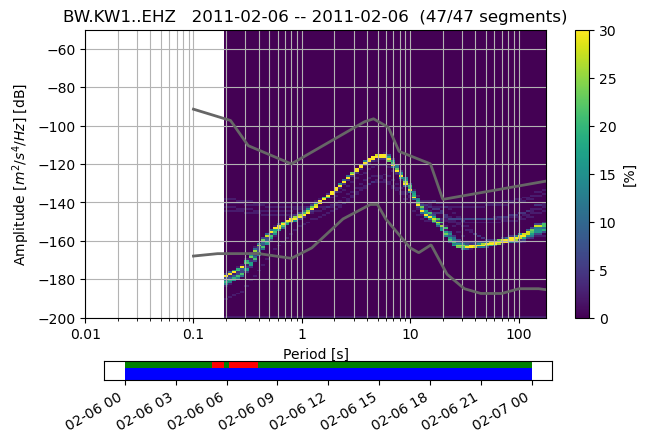

In [13]:
ppsd.plot()

### FDSN data (monkey patch to use requests instead of urllib)

/lib/python3.13/site-packages/obspy/clients/fdsn/client.py:257: ObsPyDeprecationWarning: RESIF is now EPOSFR. Webservices and client will be shutdown in 2026. Please consider changing the FDSN client short URL to 'EPOSFR'.
  warnings.warn(msg, ObsPyDeprecationWarning)


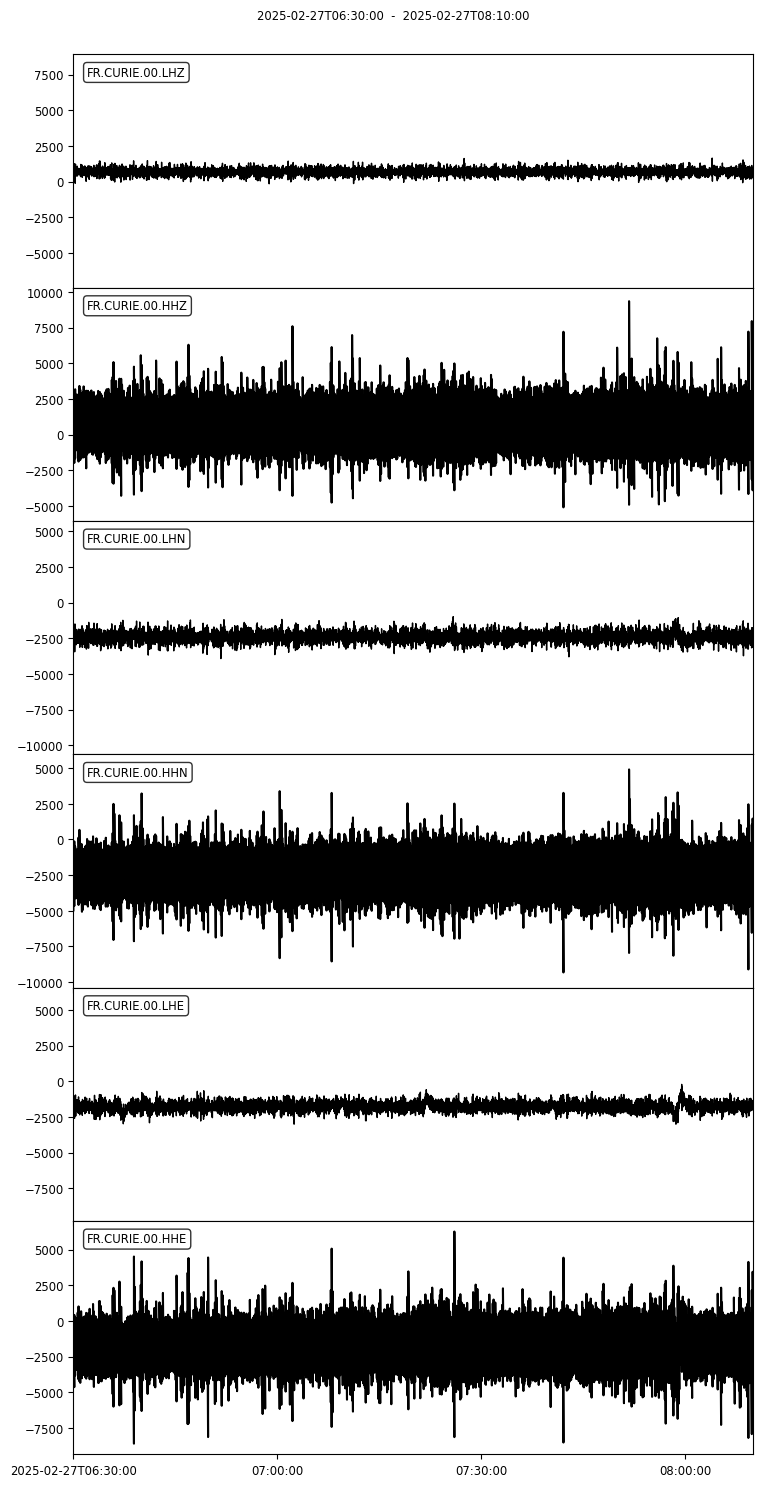

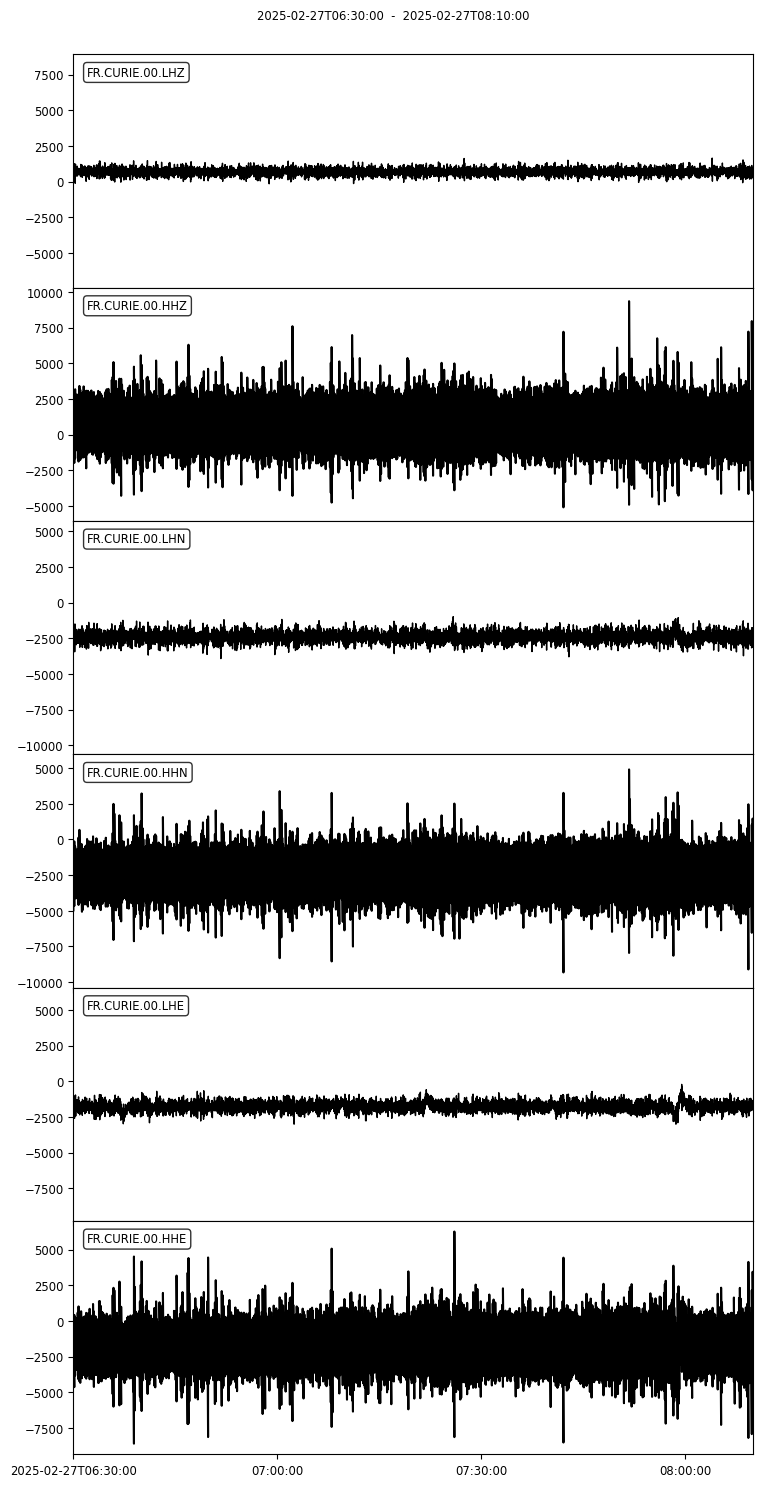

In [14]:
from obspy.clients.fdsn import client
from obspy import UTCDateTime
iris = client.Client("RESIF", _discover_services=False)
t1 = UTCDateTime("2025-02-27T06:30:00.000")
t2 = t1 + 6000
st = iris.get_waveforms("FR", "CURIE", "*", "*", t1, t2)
st.plot()

### TauP

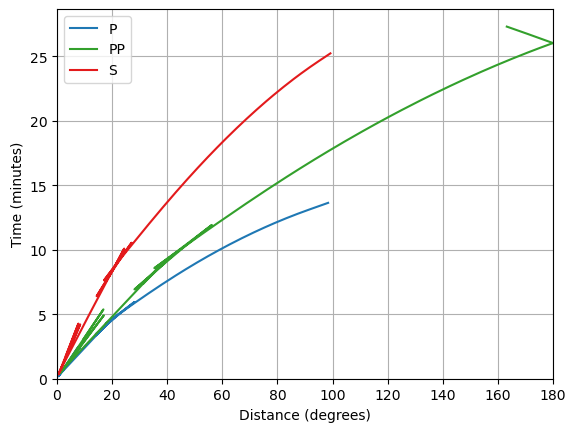

In [15]:
from obspy.taup import plot_travel_times
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax = plot_travel_times(source_depth=10, ax=ax, fig=fig, phase_list=['P', 'PP', 'S'])

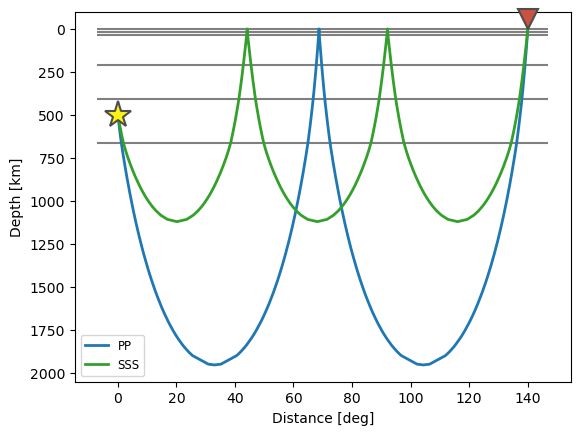

In [16]:
from obspy.taup import TauPyModel

model = TauPyModel(model='iasp91')
arrivals = model.get_ray_paths(500, 140, phase_list=['PP', 'SSS'])
arrivals.plot_rays(plot_type='cartesian', phase_list=['PP', 'SSS'], plot_all=False, legend=True);

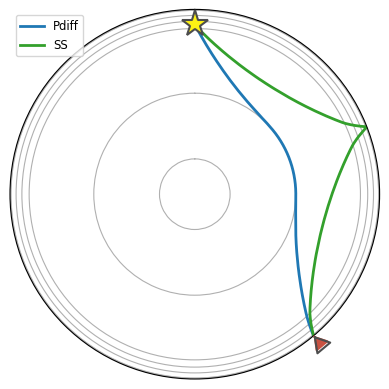

In [17]:
from obspy.taup import TauPyModel

model = TauPyModel(model='iasp91')
arrivals = model.get_ray_paths(500, 140, phase_list=['Pdiff', 'SS'])
arrivals.plot_rays(plot_type='spherical', phase_list=['Pdiff', 'SS'], legend=True);

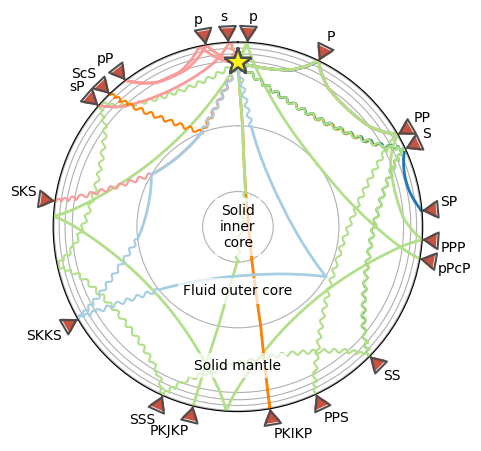

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from obspy.taup import TauPyModel


PHASES = [
    # Phase, distance
    ('P', 26),
    ('PP', 60),
    ('PPP', 94),
    ('PPS', 155),
    ('p', 3),
    ('pPcP', 100),
    ('PKIKP', 170),
    ('PKJKP', 194),
    ('S', 65),
    ('SP', 85),
    ('SS', 134.5),
    ('SSS', 204),
    ('p', -10),
    ('pP', -37.5),
    ('s', -3),
    ('sP', -49),
    ('ScS', -44),
    ('SKS', -82),
    ('SKKS', -120),
]

model = TauPyModel(model='iasp91')

fig, ax = plt.subplots(subplot_kw=dict(polar=True))

# Plot all pre-determined phases
for phase, distance in PHASES:
    arrivals = model.get_ray_paths(700, distance, phase_list=[phase])
    ax = arrivals.plot_rays(plot_type='spherical',
                            legend=False, label_arrivals=True,
                            plot_all=True,
                            show=False, ax=ax, indicate_wave_type=True)

# Annotate regions
ax.text(0, 0, 'Solid\ninner\ncore',
        horizontalalignment='center', verticalalignment='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
ocr = (model.model.radius_of_planet -
       (model.model.s_mod.v_mod.iocb_depth +
        model.model.s_mod.v_mod.cmb_depth) / 2)
ax.text(np.deg2rad(180), ocr, 'Fluid outer core',
        horizontalalignment='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
mr = model.model.radius_of_planet - model.model.s_mod.v_mod.cmb_depth / 2
ax.text(np.deg2rad(180), mr, 'Solid mantle',
        horizontalalignment='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.show()

### Beamforming

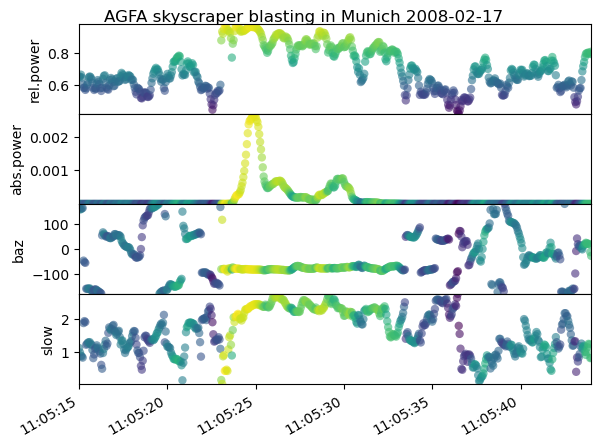

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from obspy.io.mseed.core import _read_mseed
import obspy
from obspy.core.util import AttribDict
from obspy.imaging.cm import obspy_sequential
from obspy.signal.invsim import corn_freq_2_paz
from obspy.signal.array_analysis import array_processing

# Load data
st = _read_mseed("data/agfa.mseed")

# Set PAZ and coordinates for all 5 channels
st[0].stats.paz = AttribDict({
    'poles': [(-0.03736 - 0.03617j), (-0.03736 + 0.03617j)],
    'zeros': [0j, 0j],
    'sensitivity': 205479446.68601453,
    'gain': 1.0})
st[0].stats.coordinates = AttribDict({
    'latitude': 48.108589,
    'elevation': 0.450000,
    'longitude': 11.582967})

st[1].stats.paz = AttribDict({
    'poles': [(-0.03736 - 0.03617j), (-0.03736 + 0.03617j)],
    'zeros': [0j, 0j],
    'sensitivity': 205479446.68601453,
    'gain': 1.0})
st[1].stats.coordinates = AttribDict({
    'latitude': 48.108192,
    'elevation': 0.450000,
    'longitude': 11.583120})

st[2].stats.paz = AttribDict({
    'poles': [(-0.03736 - 0.03617j), (-0.03736 + 0.03617j)],
    'zeros': [0j, 0j],
    'sensitivity': 250000000.0,
    'gain': 1.0})
st[2].stats.coordinates = AttribDict({
    'latitude': 48.108692,
    'elevation': 0.450000,
    'longitude': 11.583414})

st[3].stats.paz = AttribDict({
    'poles': [(-4.39823 + 4.48709j), (-4.39823 - 4.48709j)],
    'zeros': [0j, 0j],
    'sensitivity': 222222228.10910088,
    'gain': 1.0})
st[3].stats.coordinates = AttribDict({
    'latitude': 48.108456,
    'elevation': 0.450000,
    'longitude': 11.583049})

st[4].stats.paz = AttribDict({
    'poles': [(-4.39823 + 4.48709j), (-4.39823 - 4.48709j), (-2.105 + 0j)],
    'zeros': [0j, 0j, 0j],
    'sensitivity': 222222228.10910088,
    'gain': 1.0})
st[4].stats.coordinates = AttribDict({
    'latitude': 48.108730,
    'elevation': 0.450000,
    'longitude': 11.583157})


# Instrument correction to 1Hz corner frequency
paz1hz = corn_freq_2_paz(1.0, damp=0.707)
st.simulate(paz_remove='self', paz_simulate=paz1hz)

# Execute array_processing
stime = obspy.UTCDateTime("20080217110515")
etime = obspy.UTCDateTime("20080217110545")
kwargs = dict(
    # slowness grid: X min, X max, Y min, Y max, Slow Step
    sll_x=-3.0, slm_x=3.0, sll_y=-3.0, slm_y=3.0, sl_s=0.03,
    # sliding window properties
    win_len=1.0, win_frac=0.05,
    # frequency properties
    frqlow=1.0, frqhigh=8.0, prewhiten=0,
    # restrict output
    semb_thres=-1e9, vel_thres=-1e9, timestamp='mlabday',
    stime=stime, etime=etime
)
out = array_processing(st, **kwargs)

# Plot
labels = ['rel.power', 'abs.power', 'baz', 'slow']

xlocator = mdates.AutoDateLocator()
fig = plt.figure()
for i, lab in enumerate(labels):
    ax = fig.add_subplot(4, 1, i + 1)
    ax.scatter(out[:, 0], out[:, i + 1], c=out[:, 1], alpha=0.6,
               edgecolors='none', cmap=obspy_sequential)
    ax.set_ylabel(lab)
    ax.set_xlim(out[0, 0], out[-1, 0])
    ax.set_ylim(out[:, i + 1].min(), out[:, i + 1].max())
    ax.xaxis.set_major_locator(xlocator)
    ax.xaxis.set_major_formatter(mdates.AutoDateFormatter(xlocator))

fig.suptitle('AGFA skyscraper blasting in Munich %s' % (
    stime.strftime('%Y-%m-%d'), ))
fig.autofmt_xdate()
fig.subplots_adjust(left=0.15, top=0.95, right=0.95, bottom=0.2, hspace=0)
plt.show()

## Further Info on Installation

### Example data files that are available

In [20]:
from obspy.core.util.base import ALL_MODULES  
import os  
  
# Search through all modules for available example files  
available_files = []
for module in ALL_MODULES:
    try:  
        mod = __import__("obspy.%s" % module, fromlist=["obspy"])  
        base_path = mod.__path__[0]
          
        # Check tests/data  
        test_data_path = os.path.join(base_path, "tests", "data")  
        if os.path.exists(test_data_path):  
            available_files.extend([f for f in os.listdir(test_data_path)])  
          
        # Check data  
        data_path = os.path.join(base_path, "data")  
        if os.path.exists(data_path):  
            available_files.extend([f for f in os.listdir(data_path)])  
    except ImportError:  
        continue  
  
print("Available example files:", sorted(set(available_files)))

Available example files: ['1066a.nd', '1066a.npz', '1066b.nd', '1066b.npz', '1T_MONN_00_EDH.xml', 'BW_GR_misc.xml', 'BW_RJOB.xml', 'BW_RJOB__EHZ.xml', 'Flinn-Engdahl.csv', 'QuakeML-1.2.rng', 'QuakeML-1.2.xsd', 'QuakeML-BED-1.2.rng', 'QuakeML-BED-1.2.xsd', 'README.txt', 'Variations-FDSNSXML-SEED.txt', 'ak135.npz', 'ak135.tvel', 'ak135f._nd', 'ak135f_no_mud.nd', 'ak135f_no_mud.npz', 'arclink_schema.xsd', 'example.npz', 'fdsn-station+availability-1.0.xsd', 'fdsn-station-1.0.xsd', 'fdsn-station-1.1.xsd', 'fdsn-station-1.2.xsd', 'herrin.nd', 'herrin.npz', 'iasp91.npz', 'iasp91.tvel', 'idc_noise_models.npz', 'jb.nd', 'jb.npz', 'names.asc', 'nesect.asc', 'noise_models.npz', 'nwsect.asc', 'pqlx.npz', 'prem.nd', 'prem.npz', 'pwdk.nd', 'pwdk.npz', 'quadsidx.asc', 'quakeml_1.2__sc3ml_0.10.xsl', 'quakeml_1.2__sc3ml_0.11.xsl', 'quakeml_1.2__sc3ml_0.12.xsl', 'quakeml_1.2__sc3ml_0.13.xsl', 'quakeml_1.2__sc3ml_0.7.xsl', 'quakeml_1.2__sc3ml_0.8.xsl', 'quakeml_1.2__sc3ml_0.9.xsl', 'quakeml_1.2__scml_0.1

## What doesn't work

### writing mseed

In [ ]:
st.write("out.mseed", format="MSEED")

/lib/python3.13/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


### Some example files not included

In [ ]:
from obspy import read_events
  
# Create catalog with typical earthquake data  
cat = read_events()
print(cat)

Unhandled error in exception handler
context: {'message': 'Exception in callback <_asyncio.TaskStepMethWrapper object at 0x1c18dd20>()', 'exception': RuntimeError("Cannot enter into task <Task pending name='Task-22' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:42>> while another task <Task pending name='Task-21' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:44>> is being executed."), 'handle': <Handle <_asyncio.TaskStepMethWrapper object at 0x1c18dd20>()>}


### Remote data blocked by CORS policy

In [ ]:
st = read('https://examples.obspy.org/RJOB_061005_072159.ehz.new')

Unhandled error in exception handler
context: {'message': 'Exception in callback <_asyncio.TaskStepMethWrapper object at 0x1fdc0728>()', 'exception': RuntimeError("Cannot enter into task <Task pending name='Task-23' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:42>> while another task <Task pending name='Task-21' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:44>> is being executed."), 'handle': <Handle <_asyncio.TaskStepMethWrapper object at 0x1fdc0728>()>}


### Cartopy Data Download (Urllib)

Fails because Cartopy uses urllib. Meanwhile monkey patching and waiting on this fix: https://github.com/SciTools/cartopy/pull/2515

### Reading from fdsn clients

#### Multithreading disallowed

In [ ]:
from obspy.clients.fdsn.client import Client
from obspy.core.utcdatetime import UTCDateTime
client = Client("LMU")

Unhandled error in exception handler
context: {'message': 'Exception in callback <_asyncio.TaskStepMethWrapper object at 0x1f4df2a0>()', 'exception': RuntimeError("Cannot enter into task <Task pending name='Task-24' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:42>> while another task <Task pending name='Task-21' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:44>> is being executed."), 'handle': <Handle <_asyncio.TaskStepMethWrapper object at 0x1f4df2a0>()>}


#### Urllib

Monkey patching until obspy moves to urllib3 or requests.

In [ ]:
from obspy.clients.fdsn.client import Client
from obspy.core.utcdatetime import UTCDateTime
client = Client("LMU", _discover_services=False)
t1 = UTCDateTime("2010-02-27T06:30:00.000")
t2 = t1 + 5
st = client.get_waveforms("IU", "ANMO", "00", "LHZ", t1, t2)

Unhandled error in exception handler
context: {'message': 'Exception in callback <_asyncio.TaskStepMethWrapper object at 0x1c1617d8>()', 'exception': RuntimeError("Cannot enter into task <Task pending name='Task-25' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:42>> while another task <Task pending name='Task-21' coro=<XPythonLoopRunner.__call__.<locals>.wrapped() running at /lib/python3.13/site-packages/xeus_python_shell/shell.py:44>> is being executed."), 'handle': <Handle <_asyncio.TaskStepMethWrapper object at 0x1c1617d8>()>}
